In [6]:
import cv2
import os
import numpy as np
from matplotlib import pyplot as plt
from PIL import Image

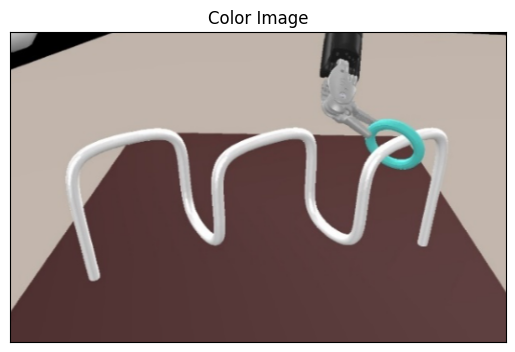

In [7]:
img = cv2.imread('path_image.png', cv2.IMREAD_COLOR)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img_rgb)
plt.title('Color Image')
plt.xticks([])
plt.yticks([])
plt.show()

plt.show()

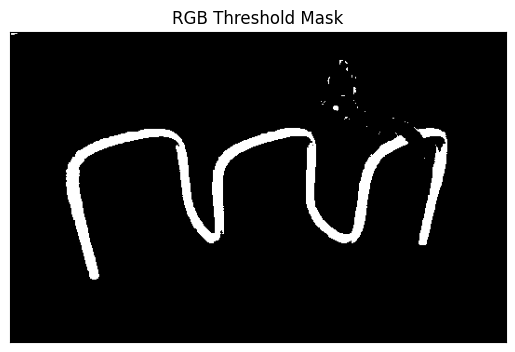

In [8]:
img = cv2.imread('path_image.png')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_rgb = img_rgb.astype(int)
diff_allowed = 10

for i in range(img_rgb.shape[0]):
    for j in range(img_rgb.shape[1]):
        if (abs(img_rgb[i, j, 0] - img_rgb[i, j, 1]) > diff_allowed
            or abs(img_rgb[i, j, 0] - img_rgb[i, j, 2]) > diff_allowed
            or abs(img_rgb[i, j, 1] - img_rgb[i, j, 2]) > diff_allowed) or (img_rgb[i, j, 0] < 185):
            img_rgb[i, j, 0] = 0
            img_rgb[i, j, 1] = 0
            img_rgb[i, j, 2] = 0
        else:
            img_rgb[i, j, 0] = 255
            img_rgb[i, j, 1] = 255
            img_rgb[i, j, 2] = 255

plt.imshow(img_rgb)
plt.title('RGB Threshold Mask')
plt.xticks([])
plt.yticks([])
plt.show()

img_rgb = img_rgb.astype(np.uint8)

In [13]:
def get_next_coord(last_coord, current_coord):
  min_dist = 5
  max_dist = 15

  current_direction = (current_coord[0] - last_coord[0], current_coord[1] - last_coord[1])
  current_angle = np.arctan2(current_direction[1], current_direction[0])

  coord_opt_1 = (0, 0)
  coord_opt_2 = (0, 0)

  for i in range(img_rgb.shape[0]):
      for j in range(img_rgb.shape[1]):
          if img_rgb[i, j, 0] == 255:
              distance = np.linalg.norm(np.array((j, i)) - np.array(current_coord))
              distance_last = np.linalg.norm(np.array((j, i)) - np.array(last_coord))
              new_direction = (j - current_coord[0], i - current_coord[1])
              new_angle = np.arctan2(new_direction[1], new_direction[0])
              if distance >= min_dist and distance <= max_dist and (new_angle > current_angle - np.pi/2 and new_angle < current_angle + np.pi/2):
                  if coord_opt_1 == (0, 0):
                      coord_opt_1 = (j, i)
                  else:
                      coord_opt_2 = (j, i)

  next_coord = np.average((np.array(coord_opt_1), np.array(coord_opt_2)), axis=0)
  next_coord = np.round(next_coord).astype(int)
  next_coord = tuple(next_coord)
  return next_coord

[(90, 260), (np.int64(88), np.int64(252)), (np.int64(86), np.int64(244)), (np.int64(84), np.int64(236)), (np.int64(82), np.int64(228)), (np.int64(80), np.int64(220)), (np.int64(78), np.int64(212)), (np.int64(76), np.int64(204)), (np.int64(74), np.int64(196)), (np.int64(72), np.int64(188)), (np.int64(70), np.int64(180)), (np.int64(68), np.int64(172)), (np.int64(66), np.int64(164)), (np.int64(64), np.int64(156)), (np.int64(68), np.int64(148)), (np.int64(70), np.int64(142)), (np.int64(74), np.int64(135)), (np.int64(80), np.int64(130)), (np.int64(87), np.int64(126)), (np.int64(95), np.int64(122)), (np.int64(102), np.int64(120)), (np.int64(110), np.int64(116)), (np.int64(117), np.int64(114)), (np.int64(123), np.int64(113)), (np.int64(127), np.int64(112)), (np.int64(136), np.int64(110)), (np.int64(143), np.int64(109)), (np.int64(146), np.int64(108)), (np.int64(148), np.int64(108)), (np.int64(155), np.int64(108)), (np.int64(164), np.int64(108)), (np.int64(172), np.int64(110)), (np.int64(178),

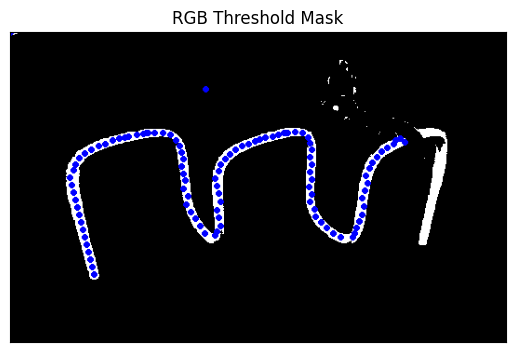

In [14]:
center_coordinates = (90, 260)
all_coords = [center_coordinates]
all_coords.append(get_next_coord((95,265), center_coordinates))
while all_coords[-1] != (0, 0):
    all_coords.append(get_next_coord(all_coords[-2], all_coords[-1]))

print(all_coords)

radius = 2
color = (0, 0, 255)
thickness = 2
copied_img = img_rgb.copy()
# cv2.circle(copied_img, (138,110), radius, color, thickness)

for coords in all_coords:
    cv2.circle(copied_img, coords, radius, color, thickness)
plt.imshow(copied_img)
plt.title('RGB Threshold Mask')
plt.xticks([])
plt.yticks([])
plt.show()